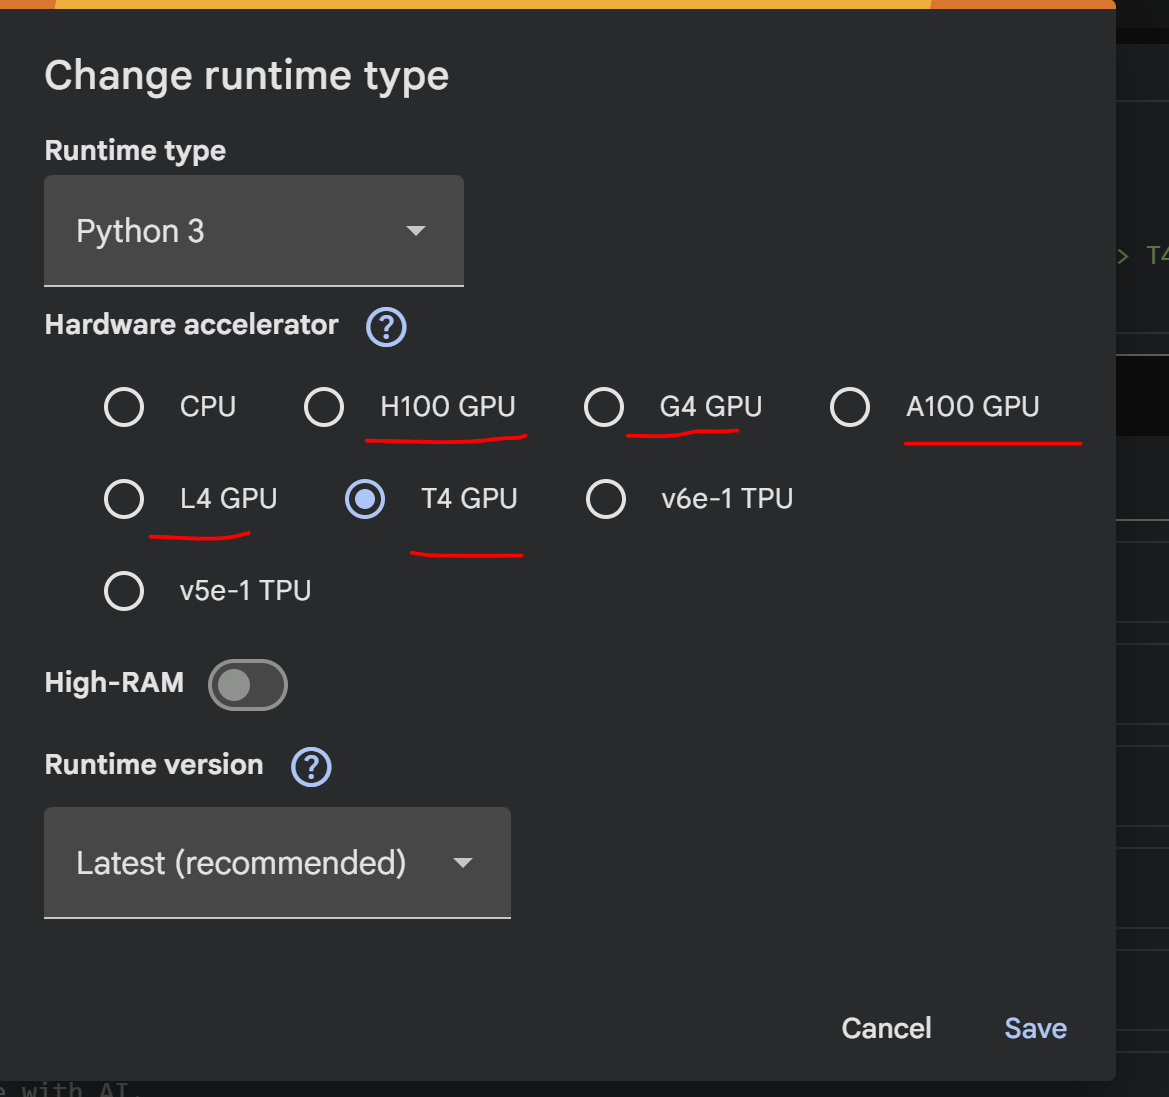

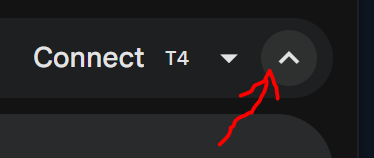

In [ ]:
print("Начинаем установку. Возможны предупреждения о зависимостях — это нормально для Colab.\n")

!pip install --upgrade pip -q
!pip install polars duckdb pyarrow fireducks -q


%load_ext cudf.pandas

print("\nУстановка завершена")

Начинаем установку. Возможны предупреждения о зависимостях — это нормально для Colab.


Установка завершена. Можно воевать!


In [ ]:
import pandas as pd
import polars as pl
import duckdb
import fireducks.pandas as fd
import numpy as np
import time

print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.2


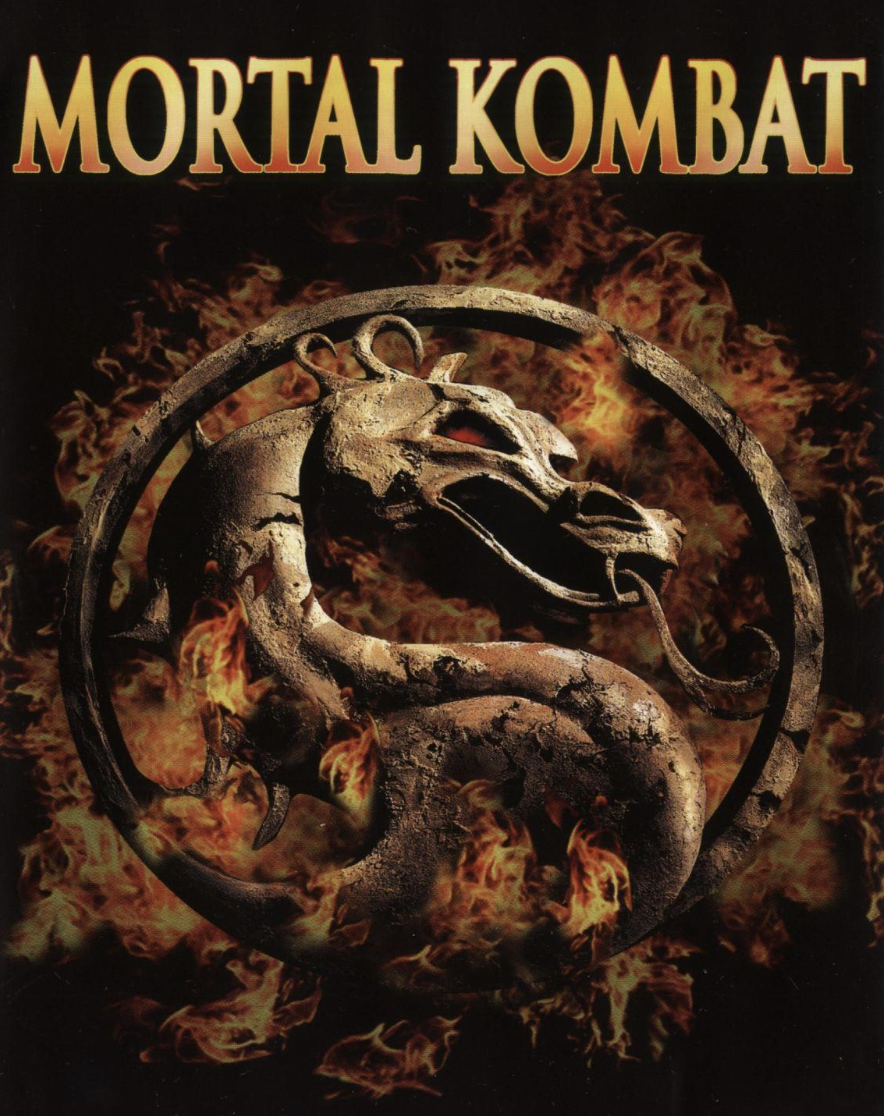

In [ ]:
# Генерация  датасета (5 млн строк)
np.random.seed(42)
N = 5_000_000
cities = ['Москва', 'СПб', 'Казань', 'Новосибирск', 'Екатеринбург']

df_pd = pd.DataFrame({
    'client_id': np.arange(N),
    'city': np.random.choice(cities, N),
    'income': np.random.randint(15000, 500001, N),
    'dti': np.round(np.random.uniform(0, 1, N), 2),
    'default': np.random.choice([True, False], N, p=[0.15, 0.85])
})

df_pd.to_parquet('/tmp/clients.parquet', index=False)
print(f"Строк: {len(df_pd):,}")

Строк: 5,000,000


In [ ]:
# средний доход по городам
results = {}

# Pandas
start = time.time()
df_pd.groupby('city')['income'].mean()
results['Pandas'] = time.time() - start

# Polars
df_pl = pl.from_pandas(df_pd)
start = time.time()
df_pl.group_by('city').agg(pl.col('income').mean())
results['Polars'] = time.time() - start

# FireDucks
df_fd = fd.DataFrame(df_pd)
start = time.time()
df_fd.groupby('city')['income'].mean()
results['FireDucks'] = time.time() - start

# DuckDB (SQL-запрос к Parquet)
start = time.time()
duckdb.query("""
    SELECT city, AVG(income) as avg_income
    FROM '/tmp/clients.parquet'
    GROUP BY city
""").to_df()
results['DuckDB'] = time.time() - start

In [ ]:
# cuDF (только с GPU!)
try:
    import importlib
    importlib.reload(pd)
    df_cudf = pd.read_parquet('/tmp/clients.parquet')
    start = time.time()
    df_cudf.groupby('city')['income'].mean()
    results['cuDF (GPU)'] = time.time() - start
    print("cuDF отработал на ура!")
except Exception as e:
    print(f"cuDF пропускает битву: {e}. Проверь, включён ли GPU (Среда выполнения → T4 GPU)")

cuDF отработал на ура!


In [ ]:
print("\n=== Итоги битвы (секунды) ===")
for lib, t in results.items():
    bar = '█' * int(t / max(results.values()) * 50)
    print(f"{lib:<15}: {t:.3f} сек {bar}")
fastest = min(results, key=results.get)
print(f"\nПобедитель: {fastest}!")


=== Итоги битвы (секунды) ===
Pandas         : 0.477 сек ██████████████████████████████████████████████████
Polars         : 0.029 сек ██
FireDucks      : 0.000 сек 
DuckDB         : 0.026 сек ██
cuDF (GPU)     : 0.438 сек █████████████████████████████████████████████

Победитель: FireDucks!


Походу Скорпион, тьфу, fireducks всег нагнул. Your soul is mine :). Get over here :)



---



---



---



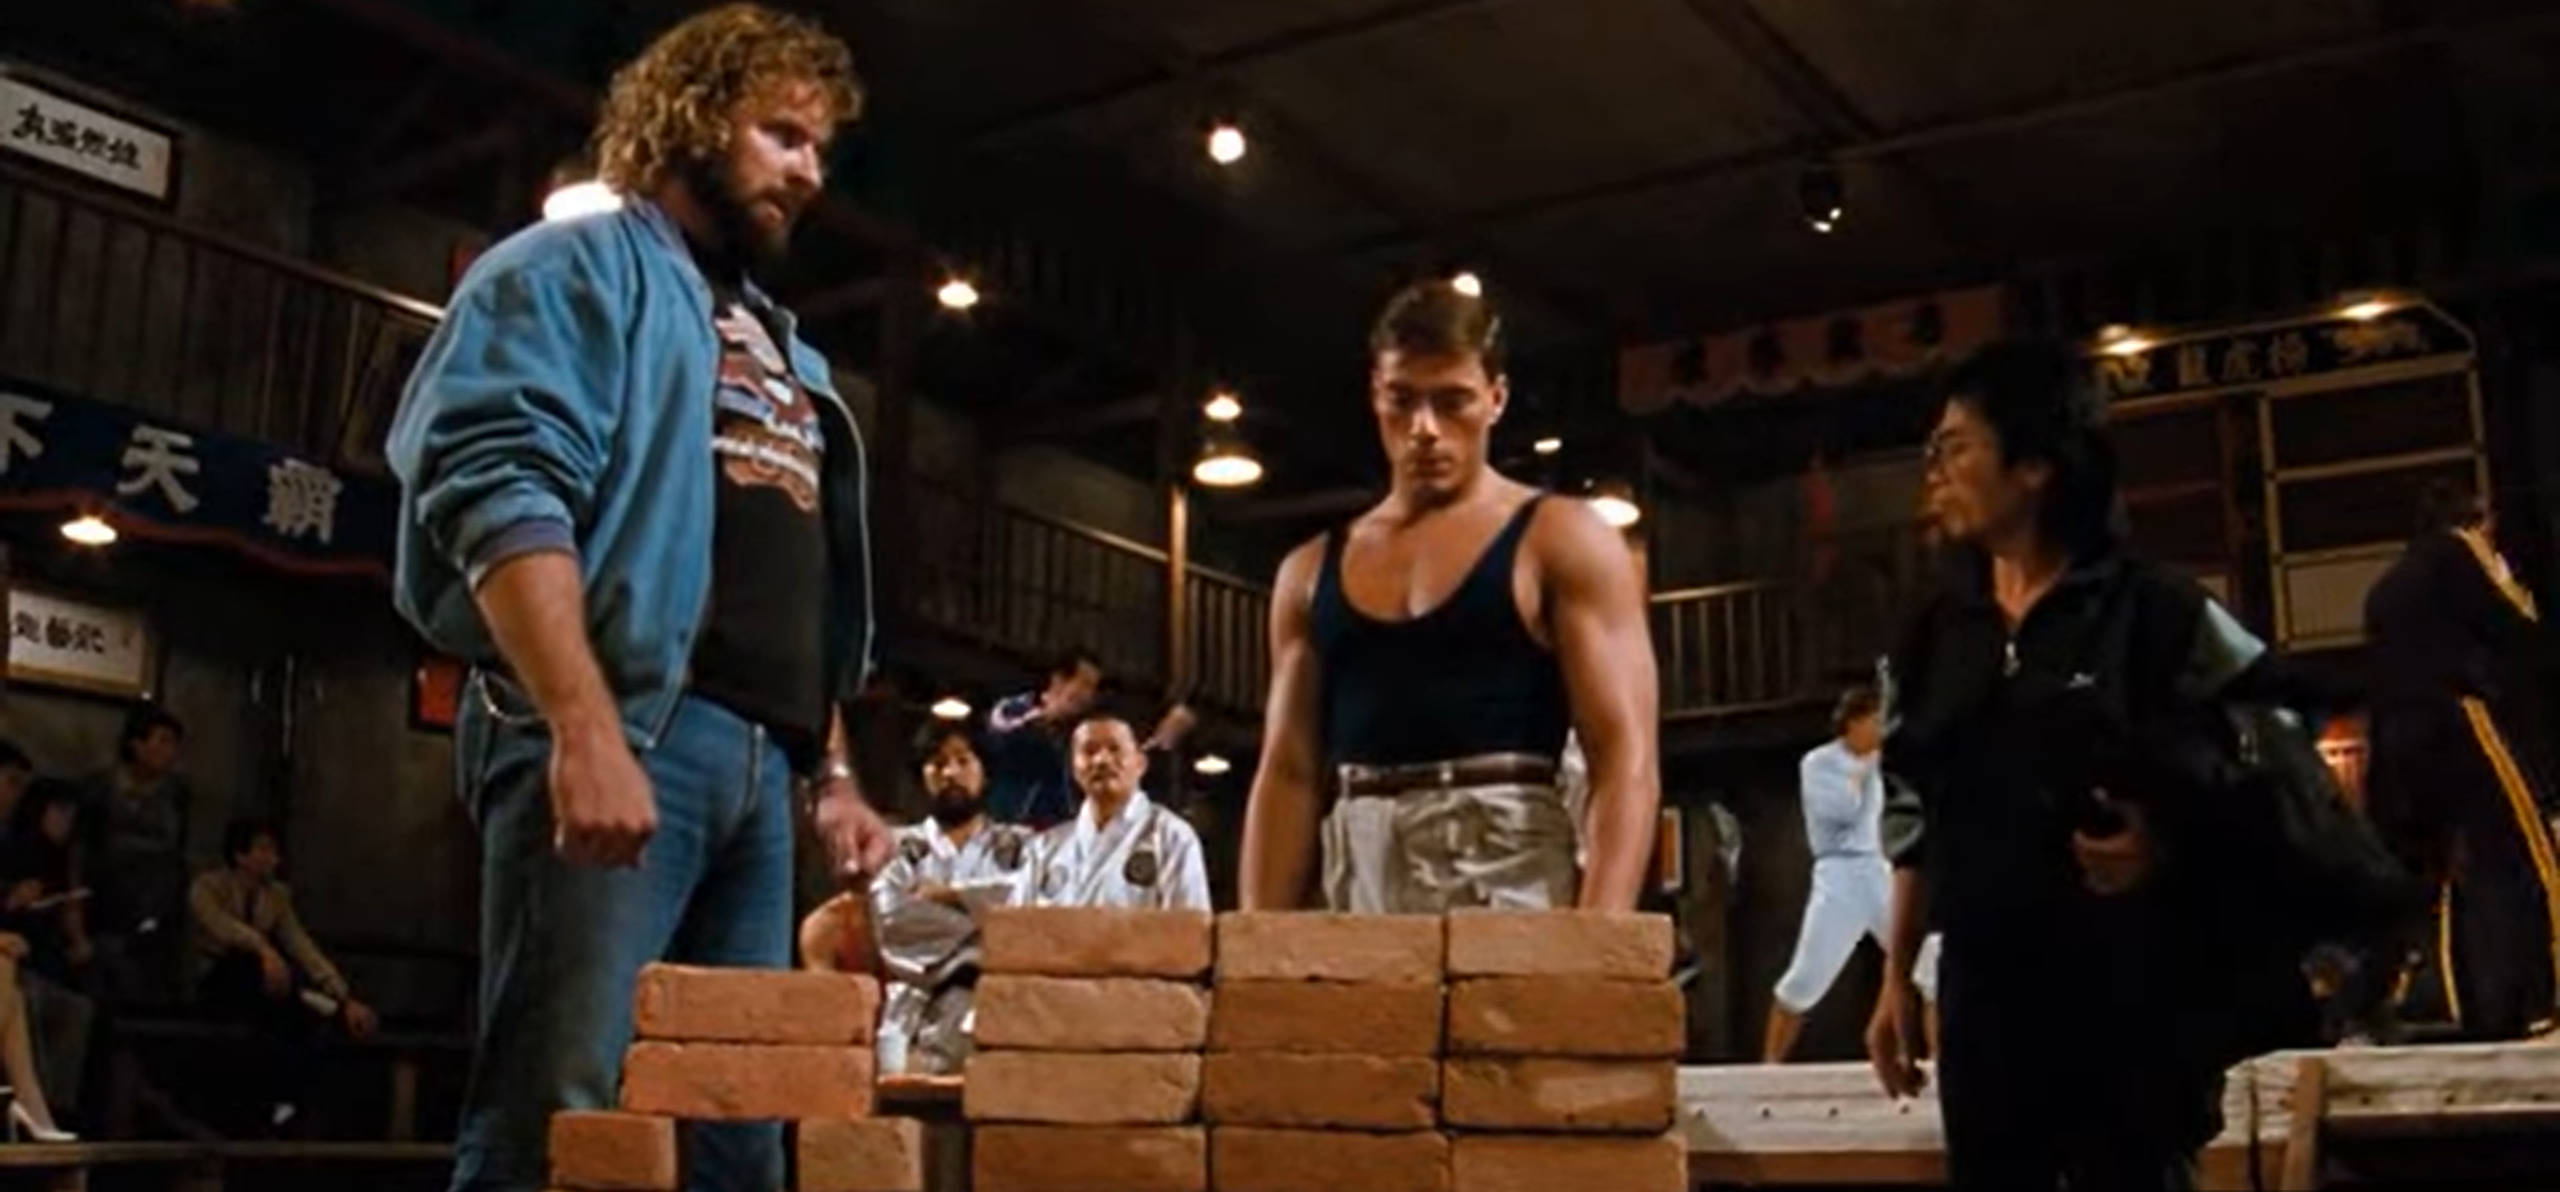

In [ ]:
#  стандартный Pandas  из Colab
!pip install --upgrade pip -q
!pip install polars duckdb pyarrow fireducks dask[complete] pyspark -q
print("Установка завершена.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00
Установка завершена.


In [ ]:
import pandas as pd
import polars as pl
import duckdb
import fireducks.pandas as fd
import dask.dataframe as dd
import dask as dask_module
from pyspark.sql import SparkSession
import numpy as np
import time


try:
    import modin.pandas as mpd
    MODIN_AVAILABLE = True
except Exception as e:
    print(f"Modin не загружен: {e}.")
    MODIN_AVAILABLE = False

print(f"Pandas: {pd.__version__}")
print(f"Polars: {pl.__version__}")
print(f"Dask: {dask_module.__version__}")

Modin не загружен: No module named 'modin'.
Pandas: 2.2.2
Polars: 1.35.2
Dask: 2026.3.0


In [ ]:
# Генерация датасета (50 млн строк)
np.random.seed(42)
N = 50_000_000
cities = ['Москва', 'СПБ', 'Казань', 'Новосибирск', 'Екатеринбург']
names = ['Иван', 'Ольга', 'Дмитрий', 'Екатерина', 'Сергей', 'Анна', 'Алексей', 'Мария']

df_pd = pd.DataFrame({
    'client_id': np.arange(N),
    'name': np.random.choice(names, N),
    'city': np.random.choice(cities, N),
    'income': np.random.randint(15000, 500001, N),
    'loan_amount': np.random.randint(50000, 5000001, N),
    'dti': np.round(np.random.uniform(0, 1, N), 2),
    'default': np.random.choice([True, False], N, p=[0.15, 0.85]),
    'app_date': pd.date_range('2026-01-01', periods=N, freq='s')
})
df_pd.to_parquet('/tmp/test.parquet', index=False)
print(f"Строк: {len(df_pd):,}")

Строк: 50,000,000


In [ ]:
# Группировка
results = {}
print("=== Группировка — средний доход по городам ===\n")

# Pandas
t0 = time.time()
df_pd.groupby('city')['income'].mean()
results['Pandas'] = time.time() - t0
print(f"Pandas: {results['Pandas']:.3f} сек")

# Polars
df_pl = pl.from_pandas(df_pd)
t0 = time.time()
df_pl.group_by('city').agg(pl.col('income').mean())
results['Polars'] = time.time() - t0
print(f"Polars: {results['Polars']:.3f} сек")

# FireDucks
df_fd = fd.DataFrame(df_pd)
t0 = time.time()
df_fd.groupby('city')['income'].mean()
results['FireDucks'] = time.time() - t0
print(f"FireDucks: {results['FireDucks']:.3f} сек")

# DuckDB
t0 = time.time()
duckdb.query("SELECT city, AVG(income) FROM '/tmp/test.parquet' GROUP BY city").to_df()
results['DuckDB'] = time.time() - t0
print(f"DuckDB: {results['DuckDB']:.3f} сек")

# Dask
ddf = dd.from_pandas(df_pd, npartitions=4)
t0 = time.time()
ddf.groupby('city')['income'].mean().compute()
results['Dask'] = time.time() - t0
print(f"Dask: {results['Dask']:.3f} сек")


=== Группировка — средний доход по городам ===

Pandas: 3.155 сек
Polars: 0.457 сек
FireDucks: 0.005 сек
DuckDB: 0.413 сек
Dask: 12.826 сек


In [ ]:
print("\n=== Итоговая таблица ===\n")
for lib, t in sorted(results.items(), key=lambda x: x[1]):
    bar = '█' * int(t / max(results.values()) * 30)
    print(f"{lib:<15}: {t:.4f} сек {bar}")
fastest = min(results, key=results.get)
print(f"\nПобедитель: {fastest}")


=== Итоговая таблица (время в секундах) ===

FireDucks      : 0.0051 сек 
DuckDB         : 0.4130 сек 
Polars         : 0.4569 сек █
Pandas         : 3.1554 сек ███████
Dask           : 12.8257 сек ██████████████████████████████

Победитель: FireDucks


Увеличивайте объем данных для генерации, добавляете еще библиотеки для сравнения, экспериментируйте! Иногда результат трудно поддается логике.Говорят, что Восток — дело тонкое. Ну я вам скажу, что рыться в данных в поисках смысла и бизнес-инсайтов — тоже дело специфическое. Истина где-то рядом (че то в моменте вспомнил про X Files)